## Historical trnd analysis, category-wise

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)
df.head()

,CPU,Mother Board,RAM,Storage,Video Card
2013-06-01,NaN,NaN,NaN,119.0,NaN
2013-07-01,NaN,NaN,NaN,0.0,NaN
2013-08-01,NaN,NaN,NaN,0.0,NaN
2013-09-01,NaN,NaN,NaN,0.0,NaN
2013-10-01,NaN,NaN,NaN,0.0,NaN


In [2]:
summary = df.agg(['mean', 'std', 'min', 'max', 'sum']).T
summary['growth_%'] = ((df.iloc[-6:].mean() - df.iloc[:6].mean()) / df.iloc[:6].mean() * 100)
summary

,mean,std,min,max,sum,growth_%
CPU,156.483871,178.724531,0.0,584.0,4851.0,NaN
Mother Board,92.903226,135.261809,0.0,557.0,2880.0,NaN
RAM,44.037037,84.022653,0.0,334.0,1189.0,NaN
Storage,91.537037,164.276425,0.0,870.0,4943.0,297.478992
Video Card,95.612903,108.023663,0.0,351.0,2964.0,NaN


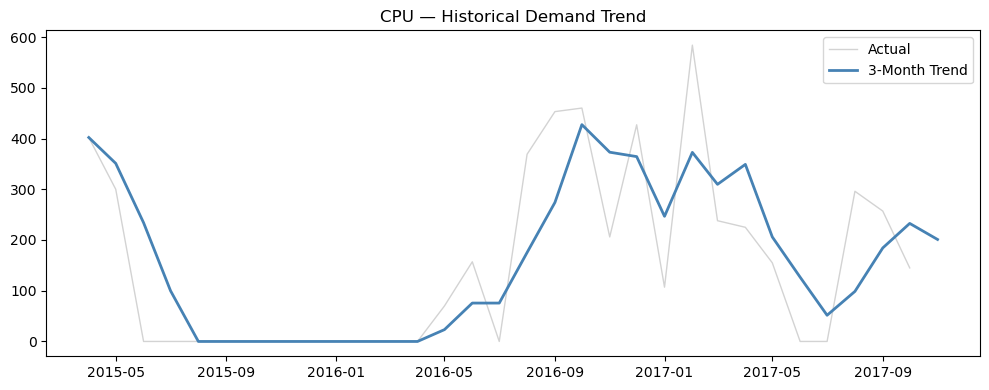

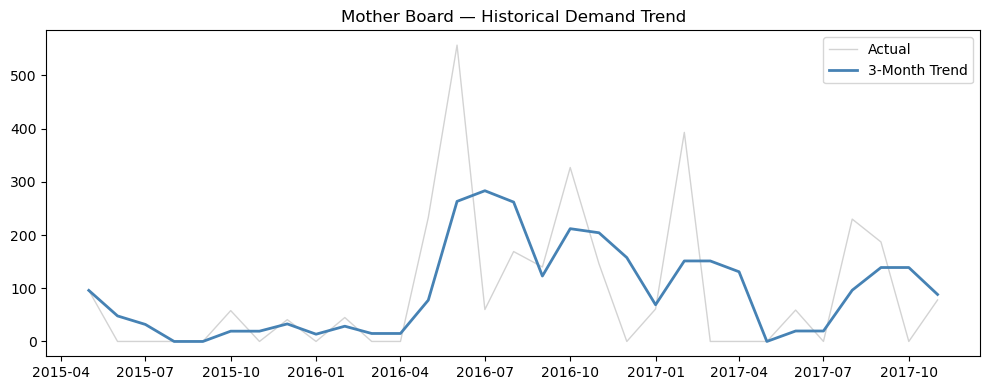

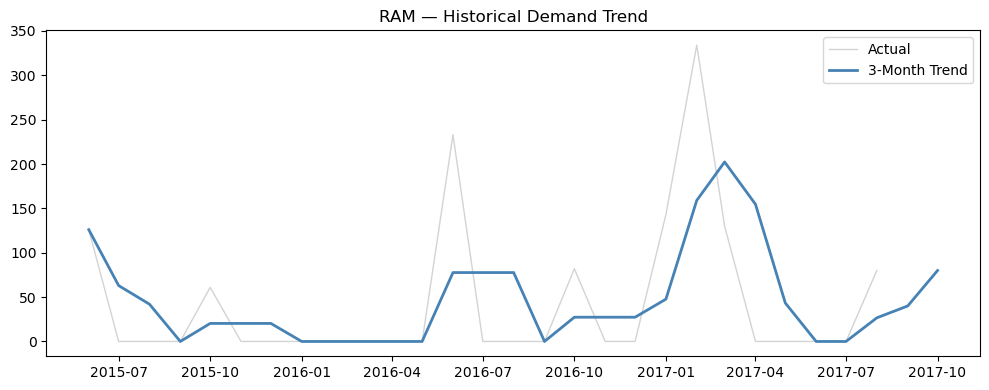

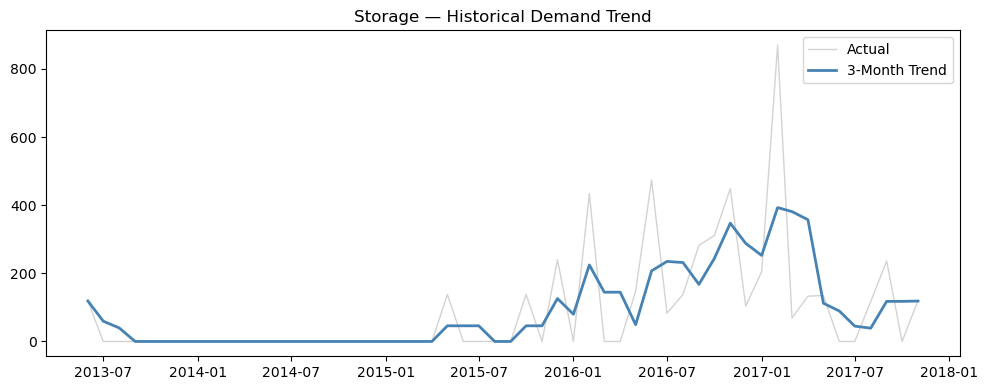

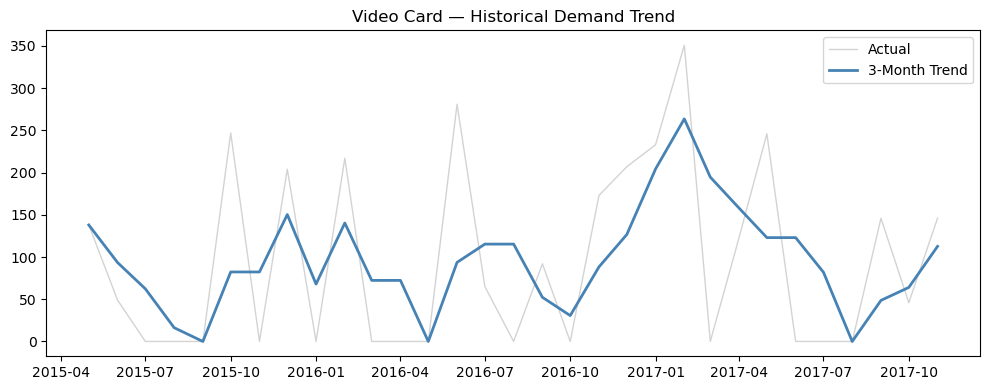

In [6]:
for cat in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df.index, df[cat], color='lightgray', label='Actual', linewidth=1)
    ax.plot(df.index, df[cat].rolling(3, min_periods=1).mean(), color='steelblue', label='3-Month Trend', linewidth=2)
    ax.set_title(f'{cat} — Historical Demand Trend')
    ax.legend()
    plt.tight_layout()
    plt.show()